In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
import shap
import warnings
warnings.filterwarnings('ignore')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", path)

100%|██████████| 0.98M/0.98M [00:00<00:00, 4.46MB/s]

Extracting files...
Path to dataset files: /Users/josethomas/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1


In [3]:
df = pd.read_csv('/Users/josethomas/Downloads/UCI_Credit_Card.csv')
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)
df.drop(columns=['ID'], inplace=True)
print(df.shape)
df.head()

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


Missing values:
 LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

Default rate: 0.2212


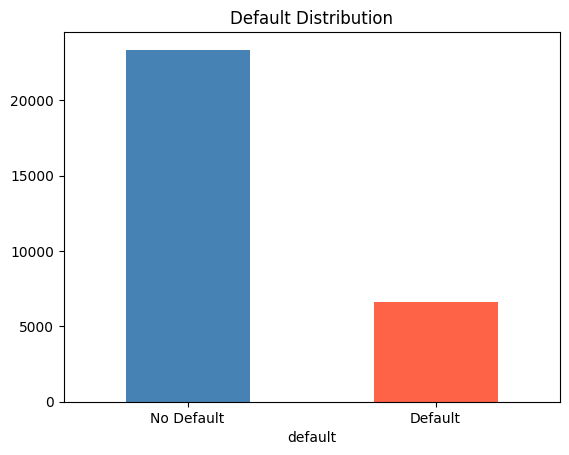

In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nDefault rate:", df['default'].mean().round(4))
df['default'].value_counts().plot(kind='bar', title='Default Distribution', color=['steelblue','tomato'])
plt.xticks([0,1], ['No Default','Default'], rotation=0)
plt.savefig('/Users/josethomas/Downloads/default_distribution.png', bbox_inches='tight')
plt.show()

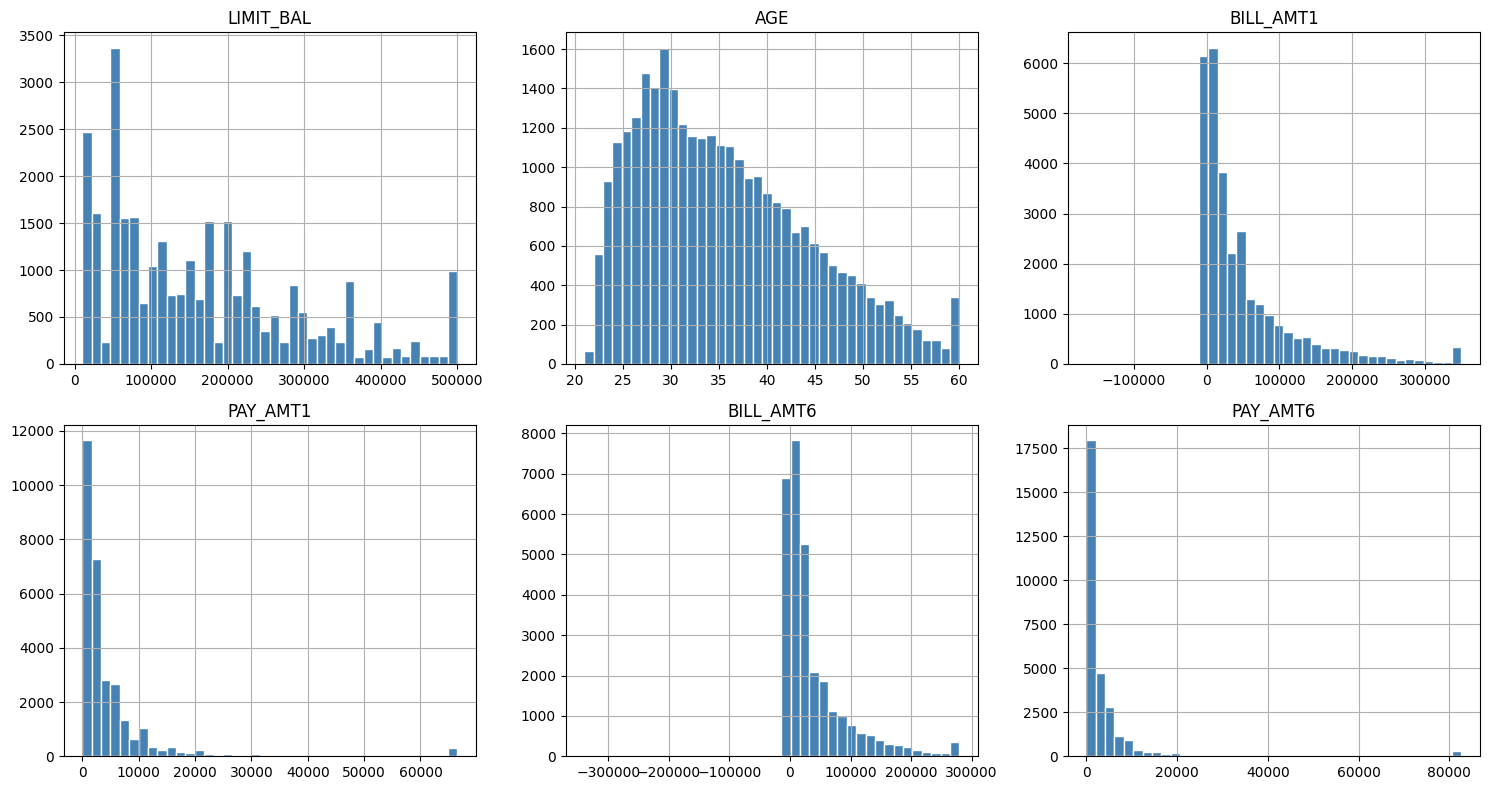

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'BILL_AMT6', 'PAY_AMT6']
for ax, col in zip(axes.flat, num_cols):
    df[col].clip(upper=df[col].quantile(0.99)).hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('/Users/josethomas/Downloads/eda_distributions.png', bbox_inches='tight')
plt.show()

In [8]:
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols  = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
pay_status_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

df['avg_utilization']    = df[bill_cols].mean(axis=1) / (df['LIMIT_BAL'] + 1)
df['total_bill']         = df[bill_cols].sum(axis=1)
df['total_paid']         = df[pay_cols].sum(axis=1)
df['payment_ratio']      = df['total_paid'] / (df['total_bill'] + 1)
df['missed_payments']    = (df[pay_status_cols] > 0).sum(axis=1)
df['payment_trend']      = df['PAY_AMT1'] - df['PAY_AMT6']  # positive = improving

print("New features added. Shape:", df.shape)
df[['avg_utilization','payment_ratio','missed_payments','payment_trend']].describe()

New features added. Shape: (30000, 30)


,avg_utilization,payment_ratio,missed_payments,payment_trend
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.373041,21.039708,0.834200,448.077933
std,0.351882,1255.771376,1.554303,21931.709545
min,-0.232585,-589.000000,0.000000,-528666.000000
25%,0.029997,0.041073,0.000000,-390.000000
50%,0.284829,0.086192,0.000000,500.000000
75%,0.687927,0.598218,1.000000,2001.250000
max,5.364040,162000.000000,6.000000,728552.000000


In [9]:
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate in train: {y_train.mean():.3f}")

Train: (24000, 29), Test: (6000, 29)
Default rate in train: 0.221


In [10]:
# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)

# Model 2: Decision Tree
dt = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

# Model 3: XGBoost
pos_weight = (y_train==0).sum() / (y_train==1).sum()
xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                    scale_pos_weight=pos_weight, random_state=42, eval_metric='auc')
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

print("All models trained.")

All models trained.


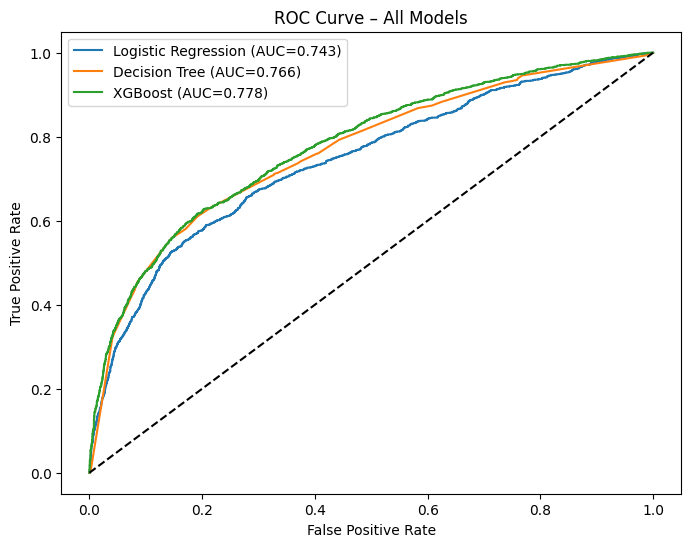

,Model,AUC-ROC,KS Statistic,Gini
0,Logistic Regression,0.7426,0.3831,0.4852
1,Decision Tree,0.7660,0.4187,0.5320
2,XGBoost,0.7777,0.4257,0.5553


In [11]:
models = {
    'Logistic Regression': (lr, X_test_sc),
    'Decision Tree':       (dt, X_test),
    'XGBoost':             (xgb, X_test)
}

results = []
plt.figure(figsize=(8,6))
for name, (model, X_eval) in models.items():
    probs = model.predict_proba(X_eval)[:,1]
    auc   = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    ks   = max(tpr - fpr)
    gini = 2*auc - 1
    results.append({'Model': name, 'AUC-ROC': round(auc,4),
                    'KS Statistic': round(ks,4), 'Gini': round(gini,4)})
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve – All Models'); plt.legend()
plt.savefig('/Users/josethomas/Downloads/roc_curve.png', bbox_inches='tight')
plt.show()

pd.DataFrame(results)

         default_rate  avg_utilization  avg_missed  count
cluster                                                  
1            0.329785         0.668291    1.656233  11086
2            0.168077         0.707263    0.483926   3546
0            0.155158         0.082954    0.322031  15365
3            0.000000         0.000000    0.333333      3


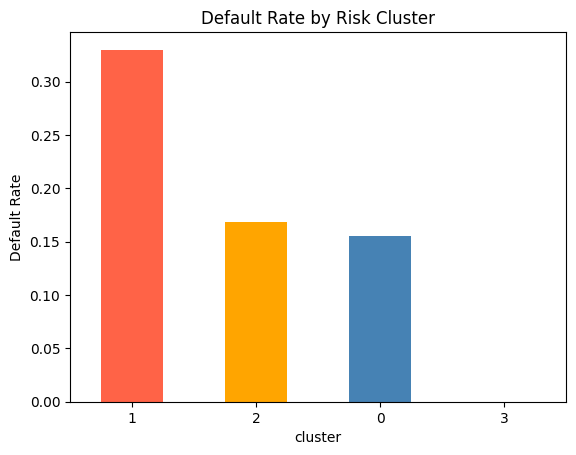

In [13]:
seg_features = ['avg_utilization','missed_payments','payment_ratio','LIMIT_BAL','total_bill']
scaler2 = StandardScaler()
X_seg = scaler2.fit_transform(df[seg_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_seg)

cluster_profile = df.groupby('cluster').agg(
    default_rate=('default','mean'),
    avg_utilization=('avg_utilization','mean'),
    avg_missed=('missed_payments','mean'),
    count=('default','count')
).sort_values('default_rate', ascending=False)

print(cluster_profile)

# Bar chart of default rate by cluster
cluster_profile['default_rate'].plot(kind='bar', color=['tomato','orange','steelblue','green'],
                                      title='Default Rate by Risk Cluster')
plt.ylabel('Default Rate'); plt.xticks(rotation=0)
plt.savefig('/Users/josethomas/Downloads/cluster_default_rates.png', bbox_inches='tight')
plt.show()

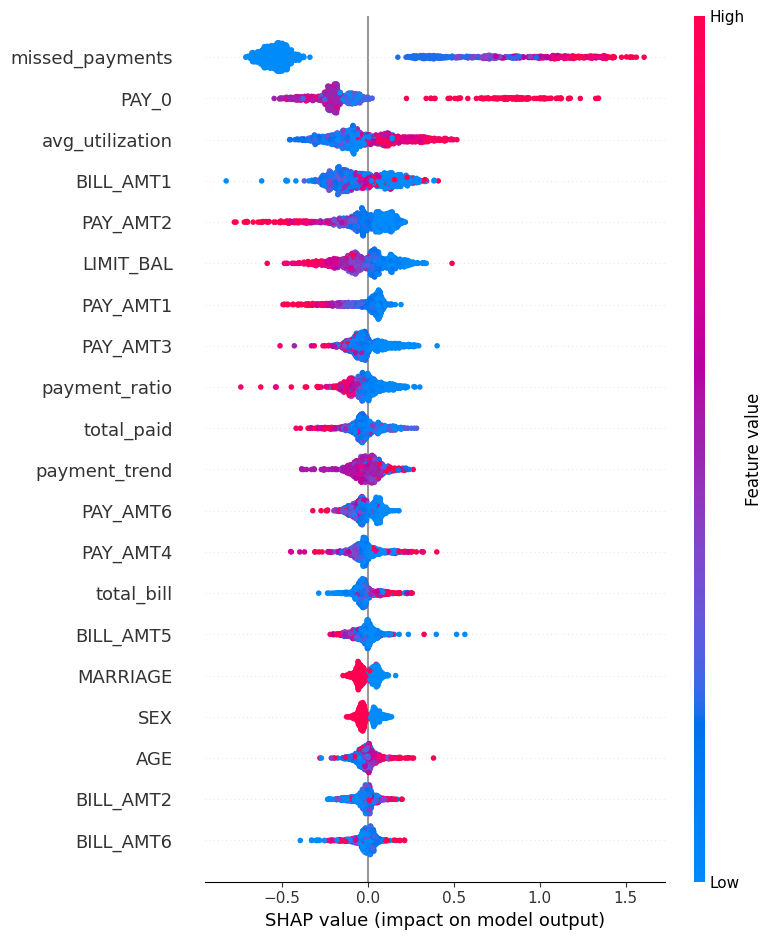

In [14]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test.iloc[:1000])

shap.summary_plot(shap_values, X_test.iloc[:1000], show=False)
plt.savefig('/Users/josethomas/Downloads/shap_summary.png', bbox_inches='tight')
plt.show()

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def load_and_clean(filepath):
    df = pd.read_csv(filepath)
    df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)
    df.drop(columns=['ID'], inplace=True)
    return df

def engineer_features(df):
    bill_cols = [f'BILL_AMT{i}' for i in range(1,7)]
    pay_cols  = [f'PAY_AMT{i}'  for i in range(1,7)]
    pay_status_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
    df['avg_utilization'] = df[bill_cols].mean(axis=1) / (df['LIMIT_BAL'] + 1)
    df['total_bill']      = df[bill_cols].sum(axis=1)
    df['total_paid']      = df[pay_cols].sum(axis=1)
    df['payment_ratio']   = df['total_paid'] / (df['total_bill'] + 1)
    df['missed_payments'] = (df[pay_status_cols] > 0).sum(axis=1)
    df['payment_trend']   = df['PAY_AMT1'] - df['PAY_AMT6']
    return df

def split_data(df, target='default', test_size=0.2):
    X = df.drop(target, axis=1)
    y = df[target]
    return train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

if __name__ == '__main__':
    df = load_and_clean('/Users/josethomas/Downloads/UCI_Credit_Card.csv')
    df = engineer_features(df)
    X_train, X_test, y_train, y_test = split_data(df)
    print(f"Pipeline complete. Train: {X_train.shape}, Test: {X_test.shape}")

Pipeline complete. Train: (24000, 29), Test: (6000, 29)
